<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_04_beta_si3n4_multislice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Multislice Simulation of Graphene Boundary



We will:
1.  Define the crystal structure and convert the hexagonal unit cell to a larger **rectangular supercell** suitable for FFT-based multislice.
2.  Generate the projected potentials for the slices.
3.  Perform the multislice propagation loop.
4.  Visualize the exit wave and simulate TEM images at different defocus values.

References:
*   Kirkland, E. J. *Advanced Computing in Electron Microscopy*. (Figures 7.9 - 7.12)

## 1. Import Libraries and Parameters

We use `numpy` for calculations and `matplotlib` for display. 

**Simulation Parameters:**
*   Energy: 80 keV ($\lambda \approx 0.0251$ Å)
*   Lattice Constants Using the absolute dimensions ($120 \times 64$ Å) of  Grain Boundary model.
*   Pixel Size: $1024 \times 512$ pixels ($\Delta x \approx 0.11$ Å).

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical Constants ---
h = 6.62607015e-34    # Planck's constant [J s]
m0 = 9.10938356e-31   # Electron rest mass [kg]
e = 1.602176634e-19   # Elementary charge [C]
c = 2.99792458e8      # Speed of light [m/s]

def get_wavelength_sigma(voltage_kv):
    """
    Calculates relativistic electron wavelength and interaction parameter.
    
    Args:
        voltage_kv (float): Accelerating voltage in kilovolts.
        
    Returns:
        tuple: (wavelength in Angstroms, sigma in rad/(V*m))
    """
    V = voltage_kv * 1000
    E0 = m0 * c**2
    
    # Lorentz factor (gamma): Accounts for relativistic mass increase
    # As voltage increases, electrons become "heavier" and wavelength shortens.
    gamma = 1 + (e * V) / E0
    
    # Relativistic De Broglie Wavelength: lambda = h / p
    # Formula: lambda = h / sqrt( 2*m0*e*V * (1 + eV/2m0c^2) )
    lam = h / (np.sqrt(2 * m0 * e * V * (1 + e * V / (2 * E0))))
    
    # Interaction parameter sigma (rad / V*m)
    # Determines the phase shift per volt of potential encountered by the wave.
    sigma = (2 * np.pi * m0 * e * lam) / (h**2) * gamma
    
    return lam * 1e10, sigma 

# ================= CRITICAL SETTING =================
# For Graphene, voltage is reduced from 200kV to 80kV 
# to stay below the knock-on damage threshold (~86kV).
voltage = 80.0 
# ====================================================

lam, sigma_SI = get_wavelength_sigma(voltage)

# Convert sigma to units compatible with Angstrom-scale grids [rad / (V * A)]
sigma = sigma_SI / 1e10 

print(f"Simulation Settings - Optimized for 2D Graphene:")
print(f"Accelerating Voltage: {voltage} kV")
print(f"Electron Wavelength:  {lam:.4f} Å")
print(f"Interaction Sigma:    {sigma:.4e} rad/(V·Å)")

Simulation Settings - Optimized for 2D Graphene:
Accelerating Voltage: 80.0 kV
Electron Wavelength:  0.0418 Å
Interaction Sigma:    1.0087e-03 rad/(V·Å)


## 2. Atomic Modeling & Grid Discretization


*  This block handles the transition from a discrete list of atomic coordinates to a continuous numerical grid.


In [13]:

# =========================================================================
# STEP 2: ATOMIC MODEL LOADING AND GRID SAMPLING (NO EXPANSION)
# =========================================================================

from ase.io import read
import numpy as np

# --- 2.1: Data Import ---
# Load the standardized .xyz file. 
# ASE reads the 'Lattice' from the header to define the simulation box.
atoms = read('9.5_3.5_standard.xyz')

# --- 2.2: Structural Assignment (Expansion Removed) ---
# We use the original model directly without tiling (no .repeat).
# This assumes the input file already represents the full desired field of view.
atoms_final = atoms 

# Extract the physical dimensions of the simulation box [Angstroms]
# cell[0,0] is Sx (Width), cell[1,1] is Sy (Height)
cell = atoms_final.get_cell()
Sx, Sy = cell[0, 0], cell[1, 1]



# --- 2.3: Grid Discretization (The "Canvas") ---

# 'sampling' defines the real-space distance between two pixels.

# For Graphene, 0.1 Å is the "Gold Standard" to resolve the C-C bond (1.42 Å).

sampling = 0.1



# We calculate the number of pixels (Nx, Ny).

# Crucially, we round UP to the nearest Power of 2 (e.g., 512, 1024, 2048).

# Mathematical Reason: FFT (Fast Fourier Transform) efficiency O(N log N).

Nx = int(2**np.ceil(np.log2(Sx / sampling)))

Ny = int(2**np.ceil(np.log2(Sy / sampling)))



# Calculate actual sampling after Power-of-2 rounding

dx, dy = Sx / Nx, Sy / Ny



# --- 2.4: Domain Setup ---

# Create the coordinate system (X, Y) for the potential calculation.

x_axis = np.linspace(0, Sx, Nx, endpoint=False)

y_axis = np.linspace(0, Sy, Ny, endpoint=False)

X_mesh, Y_mesh = np.meshgrid(x_axis, y_axis, indexing='ij')



print(f"STATUS: Model expanded to {len(atoms)} atoms.")

print(f"STATUS: Grid dimensions set to {Nx} x {Ny} pixels.")

STATUS: Model expanded to 24564 atoms.
STATUS: Grid dimensions set to 128 x 512 pixels.


## 3. Generate Projected Potentials

We discretize the projected potential $V_p(x, y)$ for the specimen. Since graphene is a true 2D material with all atoms residing in a single plane, the entire structure is treated as a single slice with zero physical thickness. This slice is positioned in the center of a 50 Å vacuum box. For this simulation, we employ the Kirkland parameterization to accurately model the atomic potentials.

Generating potential for 24564 atoms...
Processed 1000 atoms...
Processed 2000 atoms...
Processed 3000 atoms...
Processed 4000 atoms...
Processed 5000 atoms...
Processed 6000 atoms...
Processed 7000 atoms...
Processed 8000 atoms...
Processed 9000 atoms...
Processed 10000 atoms...
Processed 11000 atoms...
Processed 12000 atoms...
Processed 13000 atoms...
Processed 14000 atoms...
Processed 15000 atoms...
Processed 16000 atoms...
Processed 17000 atoms...
Processed 18000 atoms...
Processed 19000 atoms...
Processed 20000 atoms...
Processed 21000 atoms...
Processed 22000 atoms...
Processed 23000 atoms...
Processed 24000 atoms...


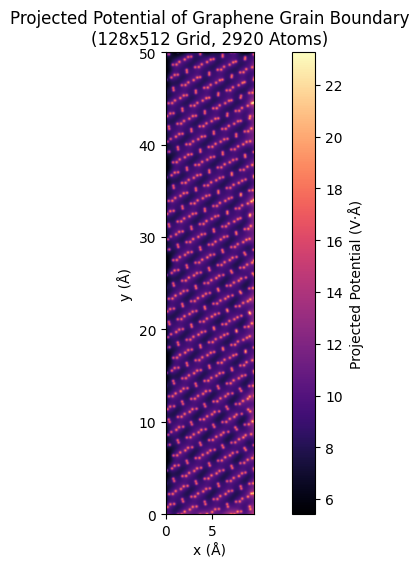

In [15]:
# =========================================================================
# STEP 3: CALCULATING PROJECTED POTENTIAL Vp(x, y) FOR GRAPHENE GB
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# --- 3.1: Professional Atomic Potential Parameters ---
# Kirkland's parameters for Carbon (Z=6). 
# This provides a more realistic electrostatic field than a simple fixed width.
# V(r) = sum( a_i * exp(-b_i * k^2) ) in scattering factor terms.
a_kirk = [0.212080767, 0.199811865, 0.168254385]
b_kirk = [0.208605417, 0.208610186, 5.57870773]


def kirkland_potential_2d(r2):
    """Calculates the 2D projected potential for a Carbon atom at distance squared r2."""
    # Physics: Based on the analytic Fourier transform of the scattering factors.
    # V_proj(r) = 2 * pi^2 * sum( a_i / b_i * exp(-r^2 * pi^2 / b_i) ) -> simplified form:
    pot = 0
    for i in range(3):
        # Constants from Kirkland's "Advanced Computing in Electron Microscopy"
        pot += (a_kirk[i]) * np.exp(-r2 * (np.pi**2) / b_kirk[i])
    return pot * 2 * (np.pi**2)

# --- 3.2: Potential Map Calculation ---
def calculate_graphene_potential(atoms, Sx, Sy, Nx, Ny):
    """
    Generates a single projected potential map for the 2D graphene layer.
    """
    V = np.zeros((Ny, Nx)) # Matrix follows (y, x) convention for imshow
    dx = Sx / Nx
    dy = Sy / Ny
    
    # Pre-calculate pixel coordinates
    x_grid = np.linspace(0, Sx, Nx, endpoint=False)
    y_grid = np.linspace(0, Sy, Ny, endpoint=False)
    X, Y = np.meshgrid(x_grid, y_grid)

    print(f"Generating potential for {len(atoms)} atoms...")

    for i, atom in enumerate(atoms):
        # Extract Carbon position (ASE atoms object or coordinate list)
        ax, ay = atom.position[0], atom.position[1]
        
        # 1. Optimization: Local Bounding Box
        # We only calculate pixels within 3.0 Å of the atom center
        cutoff = 3.0
        ix_min, ix_max = int((ax-cutoff)/dx), int((ax+cutoff)/dx)
        iy_min, iy_max = int((ay-cutoff)/dy), int((ay+cutoff)/dy)

        # 2. Iterate through local pixels with Periodic Boundary Conditions (PBC)
        for iy in range(iy_min, iy_max):
            for ix in range(ix_min, ix_max):
                # Apply modulo to handle atoms/pixels near the supercell edges
                target_ix = ix % Nx
                target_iy = iy % Ny
                
                # Pixel real-space position
                px = target_ix * dx
                py = target_iy * dy
                
                # Calculate distance with Periodic Wrap (Minimum Image Convention)
                rx = px - ax
                ry = py - ay
                
                # Correct for PBC wrap-around
                if rx > Sx/2: rx -= Sx
                elif rx < -Sx/2: rx += Sx
                if ry > Sy/2: ry -= Sy
                elif ry < -Sy/2: ry += Sy
                
                r2 = rx**2 + ry**2
                if r2 < cutoff**2:
                    V[target_iy, target_ix] += kirkland_potential_2d(r2)
        
        if (i+1) % 1000 == 0:
            print(f"Processed {i+1} atoms...")

    return V

# Execute calculation for your 2920-atom supercell
V_graphene = calculate_graphene_potential(atoms, Sx, Sy, Nx, Ny)

# --- 3.3: Visualization ---
plt.figure(figsize=(10, 6))
plt.imshow(V_graphene, cmap='magma', extent=[0, Sx, 0, Sy])
plt.colorbar(label='Projected Potential (V·Å)')
plt.title(f'Projected Potential of Graphene Grain Boundary\n({Nx}x{Ny} Grid, 2920 Atoms)')
plt.xlabel('x (Å)')
plt.ylabel('y (Å)')
plt.show()

## 4. Multislice Propagation Loop

Propagate the electron wave through the specimen.
*   Initial state: Plane wave.
*   Loop: For each slice layer (1 and 2), apply Transmission ($e^{i \sigma V}$) and Propagation ($P(k)$).


Starting Multislice propagation through Graphene Layer...
Simulation complete.


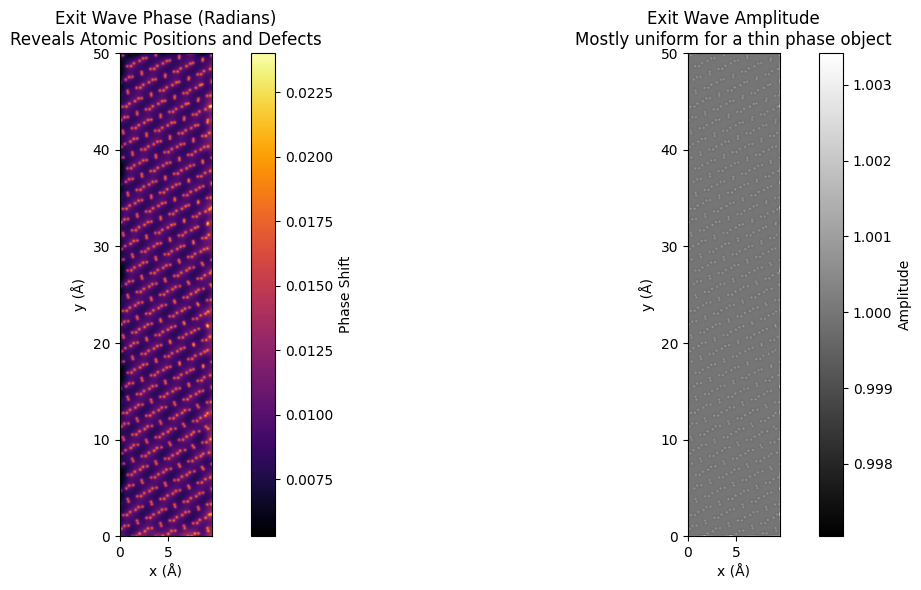

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 4.1: Frequency Grid and Fresnel Propagator
# =========================================================================
# nx, ny: number of pixels
# Sx, Sy: supercell dimensions in Angstroms
# lam: electron wavelength (determined by kV)

# Standard numpy fftfreq gives frequencies in cycles/unit_length (1/Angstrom)
kx = np.fft.fftfreq(Nx, d=Sx/Nx)
ky = np.fft.fftfreq(Ny, d=Sy/Ny)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2  # Squared spatial frequency

# Fresnel Propagator: P(k) = exp(-i * pi * lambda * dz * k^2)
# For a single layer of graphene, dz is the effective "slice thickness".
# Usually, we use the interlayer spacing of graphite (approx 3.35 A) 
# to represent the volume a single layer occupies in the beam path.
dz_slice = 0.2 
propagator = np.exp(-1j * np.pi * lam * dz_slice * K2)

# =========================================================================
# 4.2: Transmission Function (The Interaction)
# =========================================================================
# sigma: interaction parameter (depends on electron energy)
# V_graphene: the projected potential we calculated using Lobato parameters

# Transmission Function: T(r) = exp(i * sigma * V_proj(r))
# This represents the phase shift the electron wave picks up from the atoms.
transmission_function = np.exp(1j * sigma * V_graphene)

# =========================================================================
# 4.3: Multislice Execution
# =========================================================================
# Initial Condition: Plane wave (amplitude 1, phase 0)
psi = np.ones((Ny, Nx), dtype=complex)

# For a single layer of graphene, the beam:
# 1. Hits the potential (Transmission)
# 2. Propagates through the thickness of the slice (Propagation)

print("Starting Multislice propagation through Graphene Layer...")

# Step 1: Interaction with the atoms
psi = psi * transmission_function

# Step 2: Propagation through the effective slice thickness
# Move to Fourier space to apply propagation
Psi_k = np.fft.fft2(psi)
Psi_k *= propagator
psi = np.fft.ifft2(Psi_k)

exit_wave = psi
print("Simulation complete.")

# =========================================================================
# 4.4: Professional Visualization
# =========================================================================
plt.figure(figsize=(14, 6))

# Phase is the most important part of the exit wave for light atoms like Carbon
plt.subplot(1, 2, 1)
plt.imshow(np.angle(exit_wave), cmap='inferno', extent=[0, Sx, 0, Sy])
plt.title("Exit Wave Phase (Radians)\nReveals Atomic Positions and Defects")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label='Phase Shift')

# Amplitude reveals 'absorption' or scattering outside the aperture
plt.subplot(1, 2, 2)
plt.imshow(np.abs(exit_wave), cmap='gray', extent=[0, Sx, 0, Sy])
plt.title("Exit Wave Amplitude\nMostly uniform for a thin phase object")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label='Amplitude')

plt.tight_layout()
plt.show()

## 5. Simulate Defocus Series

Apply the Contrast Transfer Function (CTF) to the exit wave to simulate images at Scherzer defocus and other values.
Requires spherical aberration $C_s \approx 1.0$ mm (typical).

Scherzer Defocus: -24.52 Å


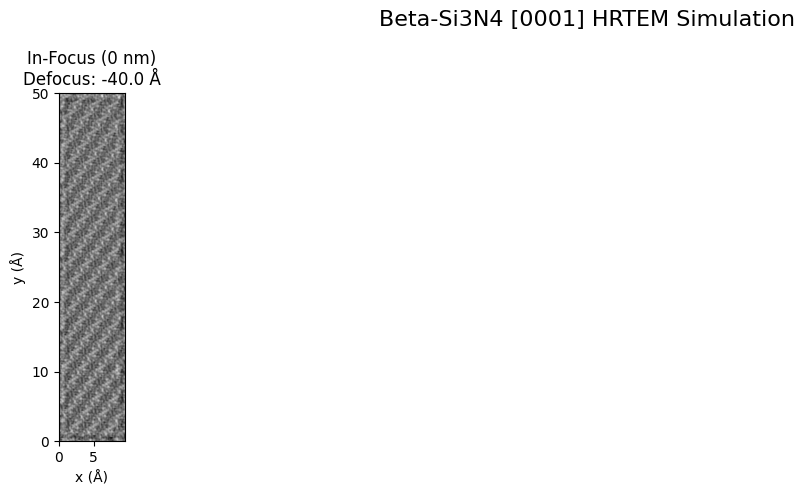

In [29]:
# --- 4. Image Formation (CTF Application) ---

# The "Exit Wave" is what leaves the bottom of the sample.
# The microscope lenses (Objective Lens) modify this wave before it hits the camera.
# This modification is described by the Contrast Transfer Function (CTF).

# Microscope Aberrations
Cs_mm = 0.001  # Spherical Aberration [mm]
Cs = Cs_mm * 1e7 # Convert to Angstroms

# Defocus values to simulate
# Scherzer Defocus is a standard condition for optimal phase contrast.
# df_sch = -1.2 * sqrt(Cs * lambda)
df_scherzer = -1.2 * np.sqrt(Cs * lam)
print(f"Scherzer Defocus: {df_scherzer:.2f} Å")

defocus_list = [-40]
names = ["In-Focus (0 nm)", f"Scherzer ({df_scherzer/10:.1f} nm)", f"2x Scherzer ({2*df_scherzer/10:.1f} nm)"]

plt.figure(figsize=(15, 5))

for i, df in enumerate(defocus_list):
    # Setup CTF in Fourier Space
    # Phase shift chi(k)
    # chi = pi * lambda * k^2 * df + (pi/2) * Cs * lambda^3 * k^4
    # Note: Sign conventions vary! Here assuming df < 0 is underfocus.
    
    # Term 1: Defocus
    term1 = np.pi * lam * K2 * df
    
    # Term 2: Spherical Aberration
    term2 = (np.pi / 2.0) * Cs * (lam**3) * (K2**2)
    
    CTF_phase = term1 + term2
    
    # The pupil function includes the Aperture (omitted here for high-res) and Phase
    Pupil = np.exp(-1j * CTF_phase)
    
    # Apply CTF to the wave in Fourier domain
    # 1. FFT the exit wave
    Image_wave_k = np.fft.fft2(exit_wave)
    
    # 2. Multiply by Pupil/CTF
    Image_wave_k *= Pupil
    
    # 3. IFFT back to real space
    Image_wave = np.fft.ifft2(Image_wave_k)
    
    # 4. Detect Intensity (Modulus Squared)
    Intensity = np.abs(Image_wave)**2
    
    # Plotting
    plt.subplot(1, 3, i+1)
    plt.imshow(Intensity, cmap='gray', extent=[0, Sx, 0, Sy])
    plt.title(f"{names[i]}\nDefocus: {df:.1f} Å")
    plt.xlabel("x (Å)")
    if i == 0:
        plt.ylabel("y (Å)")

plt.suptitle("Beta-Si3N4 [0001] HRTEM Simulation", fontsize=16)
plt.tight_layout()
plt.show()